In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# color palette
from matplotlib.colors import ListedColormap
all_colors = ['#c5aeb1', '#dc3855', '#fae199', '#ec6a37', '#f7b9c2', '#926aa6', '#c37c54', '#96bae0']
colors1 = ['#ec6a37', '#f7b9c2','#dc3855', '#926aa6']
custom_colors = ListedColormap(colors1)
custom_palette = custom_colors.colors
full_palette = ListedColormap(all_colors).colors
brand_order = ['H&M', 'Zara', 'Shein', 'Gap']
sns.set_theme(font="Georgia")

In [3]:
# rearrange by correct brand order
prices = pd.read_csv('fast_fashion_prices_item.csv')
prices['Brand'] = pd.Categorical(prices['Brand'], categories=brand_order, ordered=True)
prices = prices.sort_values(by='Brand').reset_index(drop=True)
# filter out outliers
prices_filtered = prices[prices['Price'] < 500]

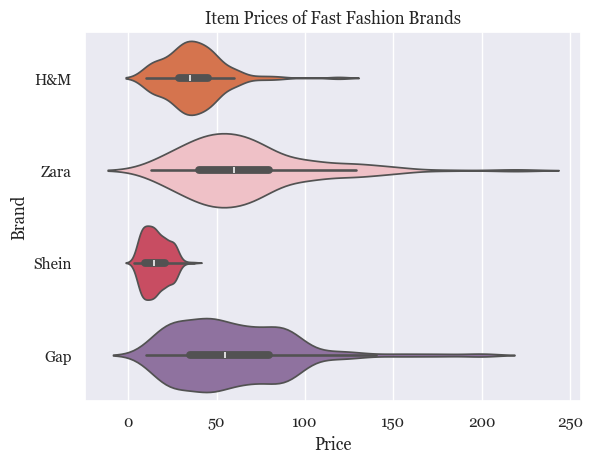

In [4]:
# violin plot
fig = sns.violinplot(data=prices_filtered, x='Price', y='Brand', hue='Brand', palette=custom_palette)
fig.set_title('Item Prices of Fast Fashion Brands')
plt.show()

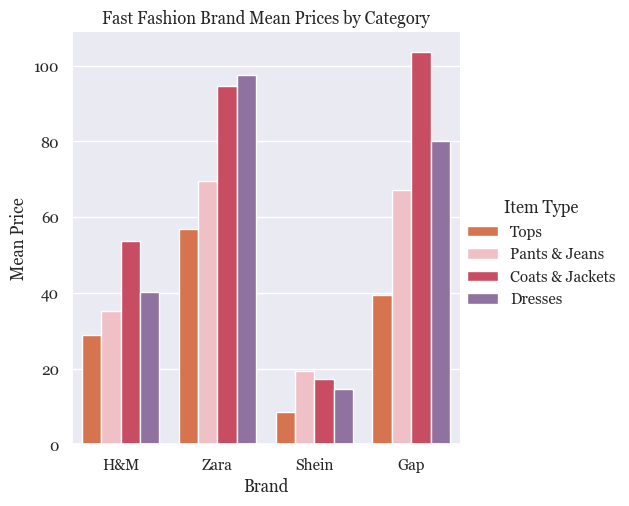

In [5]:
# mean price by item type and brand
mean_prices = prices.groupby(['Brand', 'Item Type'], observed=True)['Price'].mean()

# bar plot
fig = sns.catplot(data=prices, kind='bar', x='Brand', y='Price',
                  errorbar=None, hue='Item Type', palette=custom_palette).set(title='Fast Fashion Brand Mean Prices by Category', ylabel='Mean Price')
plt.show()

In [14]:
prices['Price Range'] = pd.cut(prices['Price'], bins=[0, 10, 30, 50, 70, 100, max(prices['Price'])], labels=['$0-$10', '$10-$30', '$30-$50', '$50-$70', '$70-$100', '$100+'])
range_counts = prices.groupby(['Brand', 'Price Range'], observed=False)['Price'].count().reset_index()
custom_palette = ListedColormap(['#c5aeb1', '#fae199', '#f7b9c2', '#926aa6',  '#ec6a37', '#dc3855', '#c37c54']).colors

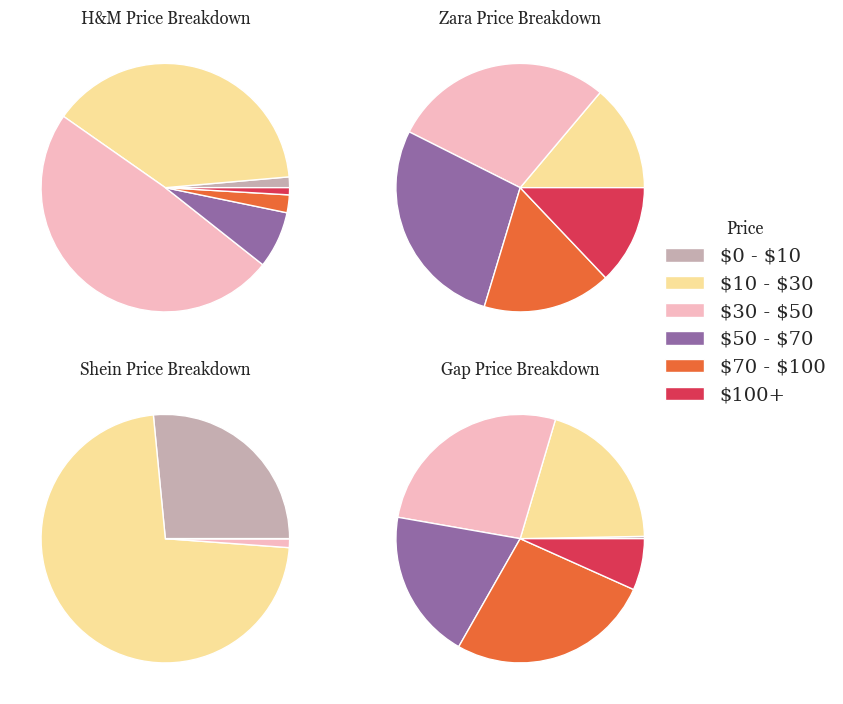

In [16]:
# pie charts

# create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# create pies
brands = pd.unique(prices['Brand'])
brand_index = 0
for i in range(2):
    for j in range(2):
        subset = range_counts[range_counts['Brand'] == brands[brand_index]]
        colors = plt.get_cmap('Set3').colors
        patches, texts = axes[i,j].pie(subset['Price'], colors=custom_palette)
        # axes[i,j].legend(patches, subset['Price Range'], title="Price", loc='upper right', bbox_to_anchor=(1, 0.5, 0.5, 0.5))
        axes[i,j].set_title(f'{brands[brand_index]} Price Breakdown')
        brand_index += 1

# fix legend labels
raw_labels = subset['Price Range'].tolist()
formatted_labels = []
for label in raw_labels:
    clean_label = label.replace('$', '').strip()
    if "-" in clean_label:
        parts = [f"\\${p.strip()}" for p in clean_label.split("-")]
        formatted_labels.append(" - ".join(parts))
    else:
        formatted_labels.append(f"\\${clean_label}")

# create legend
fig.legend(patches, formatted_labels,
           title="Price",
           loc='center right',
           prop={'family': 'serif', 'size': 14},
           bbox_to_anchor=(.9, 0.5),
           frameon=False)
plt.tight_layout(rect=[0.0, 0.0, 0.8, .9])
plt.show()